# **Importing libraries**

In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [161]:
df = pd.read_csv('StudentsPerformance.csv')

In [162]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [163]:
df.shape

(1000, 8)

In [164]:
print(df.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [165]:
print(df.duplicated().sum())

0


In [166]:
print(df.dtypes)

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object


In [167]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [168]:
for column in df.columns:
    print(column)
    print(df[column].unique())
    print('----------------')

gender
['female' 'male']
----------------
race/ethnicity
['group B' 'group C' 'group A' 'group D' 'group E']
----------------
parental level of education
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
----------------
lunch
['standard' 'free/reduced']
----------------
test preparation course
['none' 'completed']
----------------
math score
[ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]
----------------
reading score
[ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  44  41  85  59  17  39  80
  37  63  51  49  26  68  45  47  86  34  79  66  67  91 100  76  77  82
  92  93  62  8

# **Distribution of math score**

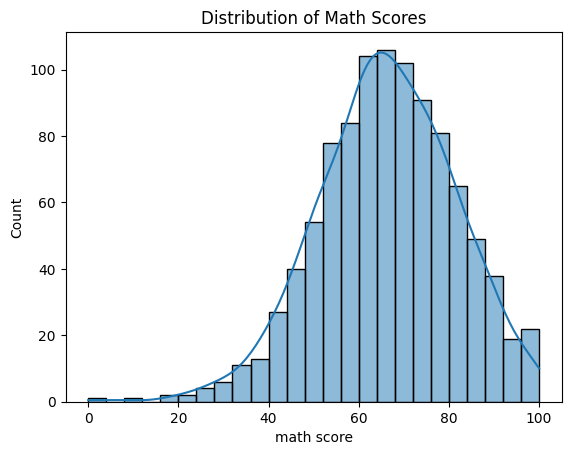

In [169]:
sns.histplot(df['math score'], kde=True)
plt.title('Distribution of Math Scores')
plt.show()

# **Gender-wise Performance**

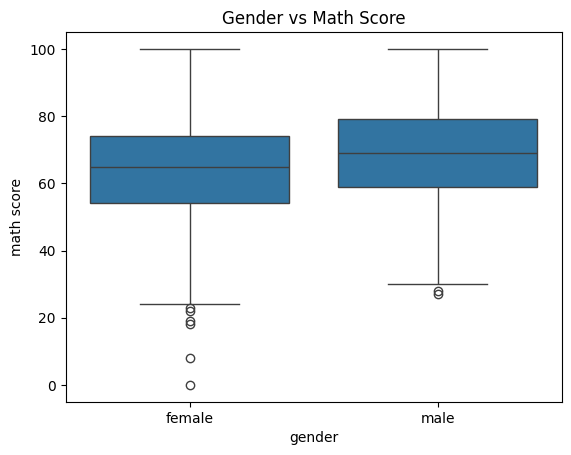

In [170]:
sns.boxplot(x='gender', y='math score', data=df)
plt.title('Gender vs Math Score')
plt.show()

# **Effect of Test Preparation Course**

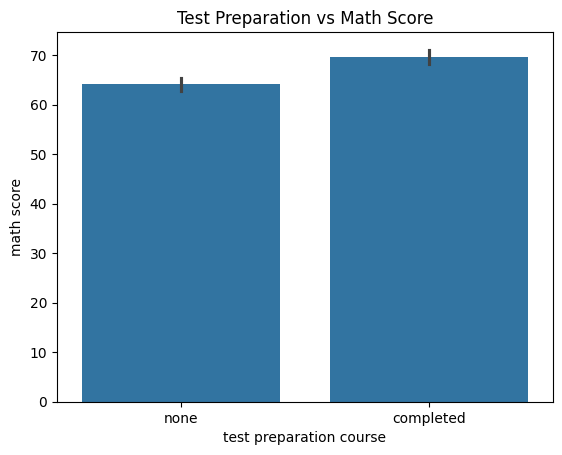

In [171]:
sns.barplot(x='test preparation course', y='math score', data=df)
plt.title('Test Preparation vs Math Score')
plt.show()

# **Correlation Heatmap**

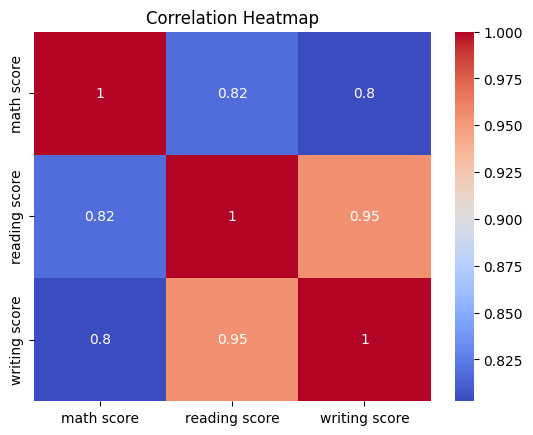

In [172]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# **Data Preprocessing**

In [173]:
X = df.drop('math score', axis=1)
y = df['math score']

In [174]:
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

print(num_features)
print(cat_features)

Index(['reading score', 'writing score'], dtype='object')
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')


In [175]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [176]:
num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

In [177]:
cat_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('one_hot_encoder', OneHotEncoder()),
        ('scaler', StandardScaler(with_mean=False))
    ]
)

In [178]:
preprocessor = ColumnTransformer(
    [
        ('num_pipeline', num_pipeline, num_features),
        ('cat_pipeline', cat_pipeline, cat_features)
    ]
)

In [179]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [180]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# **Model Training**

In [181]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

**Linear Regression**

In [182]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

**Decision Tree Regressor**

In [183]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

**Random Forest Regressor**

In [184]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

**K-Nearest Neighbors Regressor**

In [185]:
knn = KNeighborsRegressor()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

**Creation of transformer Columns**

In [186]:
num_cols=X.select_dtypes(exclude='object').columns
cat_cols=X.select_dtypes(include='object').columns

In [187]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [188]:
num_trans=StandardScaler()
oh_tran=OneHotEncoder()

In [189]:
preprocessor=ColumnTransformer(
    [
        ("OneHotEncoder",oh_tran,cat_cols),
        ("StandardScaler",num_trans,num_cols),
    ]
)

In [190]:
x=preprocessor.fit_transform(X)

In [191]:
x

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]])

In [192]:
x.shape

(1000, 19)

# **Model Evaluation**

In [193]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=23)

In [194]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2 = r2_score(true, predicted)
    return mae, rmse, r2

In [195]:
models={
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor()
}
model_list=[]
r2_list=[]


for i in range(len(list(models))):
    model = list(models.values()) [i]
    model.fit(x_train, y_train) # Train model

    #Make predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    #Evaluate Train and Test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys()) [i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('------------------------------------')

    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_rmse))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.2592
- Mean Absolute Error: 4.1681
- R2 Score: 0.8815
------------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.6218
- Mean Absolute Error: 5.6218
- R2 Score: 0.8524


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5500
- Mean Absolute Error: 5.1997
- R2 Score: 0.8162
------------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5967
- Mean Absolute Error: 6.5967
- R2 Score: 0.7967


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.2594
- Mean Absolute Error: 4.1672
- R2 Score: 0.8815
------------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.6191
- Mean Absolute Error: 5.6191
- R2 Score: 0.8525


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.7693
- Mean Absolute Error: 4.5693
- R2 Score: 0.8574
-----------------

In [196]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.852517
0,Linear Regression,0.852377
5,Random Forest Regressor,0.801555
1,Lasso,0.796734
3,K-Neighbors Regressor,0.762676
4,Decision Tree,0.642412


# **Linear Regression**

In [197]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(x_train, y_train)
y_pred = lin_model.predict(x_test)
score = r2_score(y_test, y_pred)*100
print("Accuracy of the model is %.2f" %score)

Accuracy of the model is 85.24


# **Plot y_pred and y_test**

Text(0, 0.5, 'Predicted')

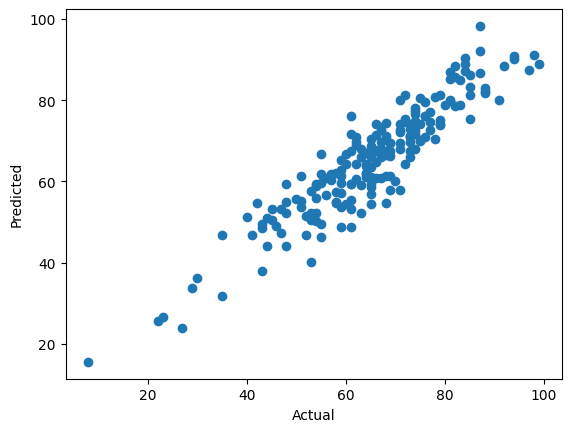

In [198]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

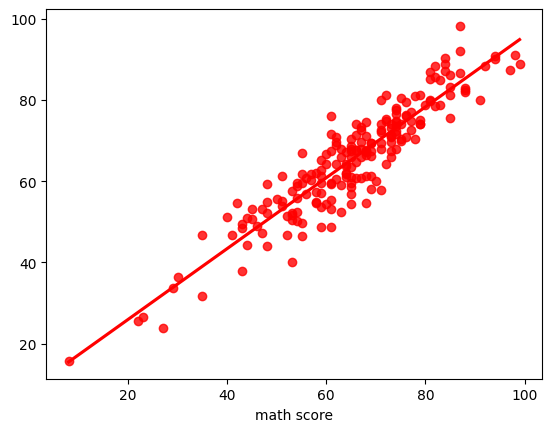

In [199]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red');

In [200]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
519,67,66.003977,0.996023
837,75,69.919265,5.080735
208,74,67.990259,6.009741
525,68,71.094116,-3.094116
978,55,49.586599,5.413401
...,...,...,...
647,64,61.992020,2.007980
481,52,46.828127,5.171873
134,74,73.568230,0.431770
366,69,57.981808,11.018192


# **Save Model**

In [201]:
import pickle

pickle.dump(rf, open('model.pkl', 'wb'))
pickle.dump(preprocessor, open('preprocessor.pkl', 'wb'))